In [92]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier


In [93]:
import pandas as pd

In [94]:
data = pd.read_excel('glass.xlsx')

In [95]:
data

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum
5,Si: Silicon
6,K:Potassium
7,Ca: Calcium
8,Ba: Barium
9,Fe: Iron


In [96]:
df=data = pd.read_excel('glass.xlsx',sheet_name=1)
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [98]:
df.shape

(214, 10)

In [99]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [100]:
df.duplicated().sum()

np.int64(1)

In [101]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [102]:
df.duplicated().sum()

np.int64(0)

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

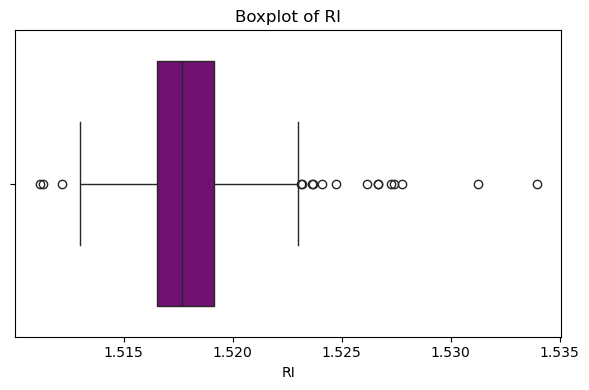

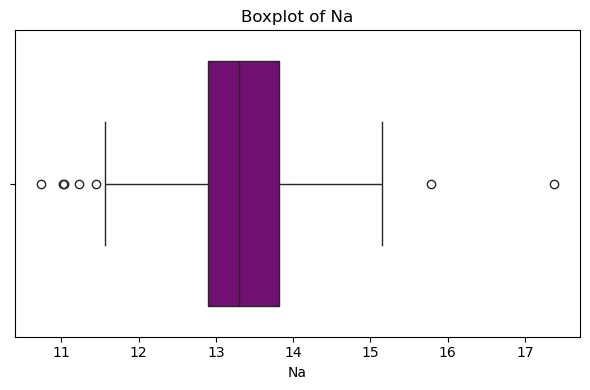

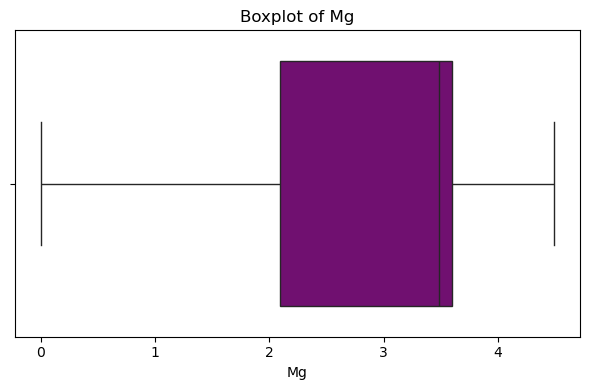

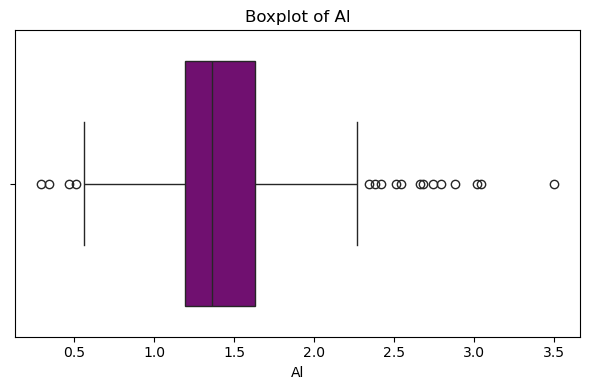

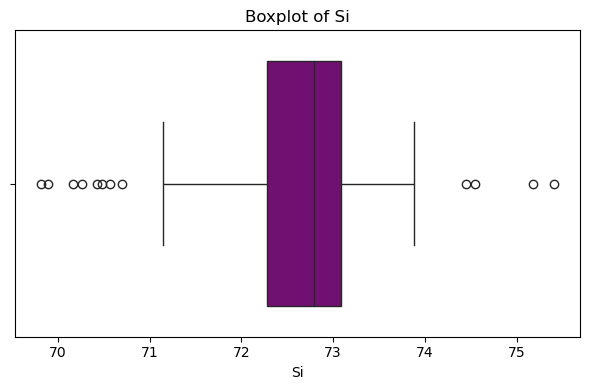

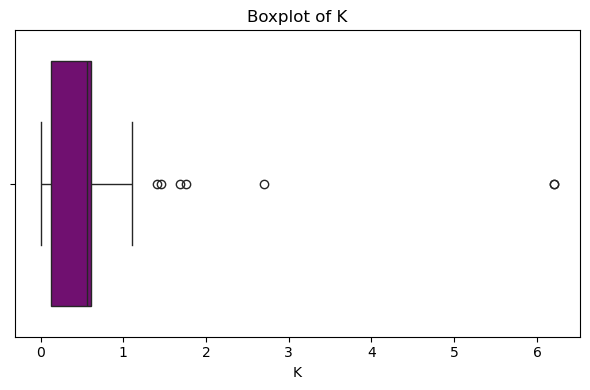

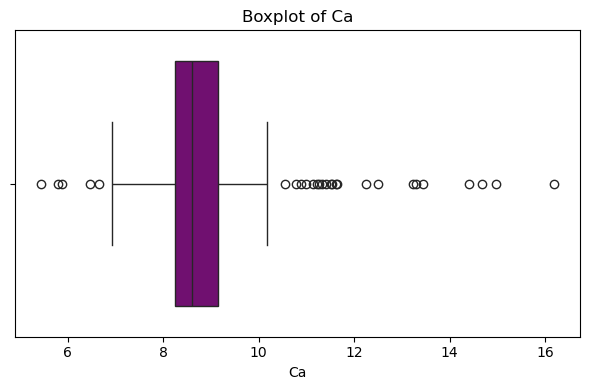

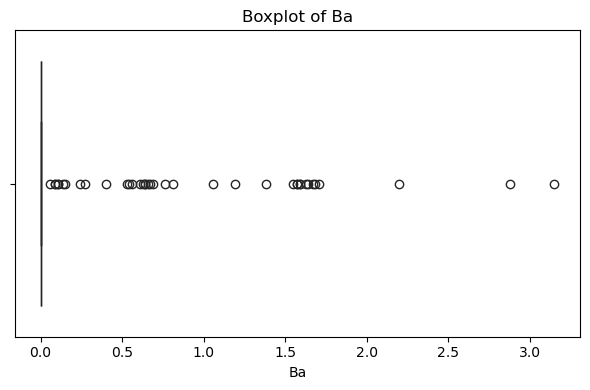

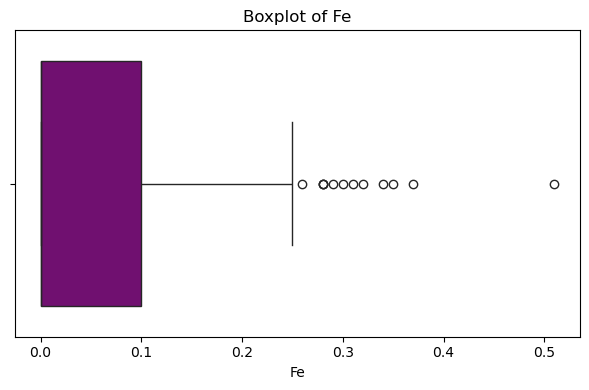

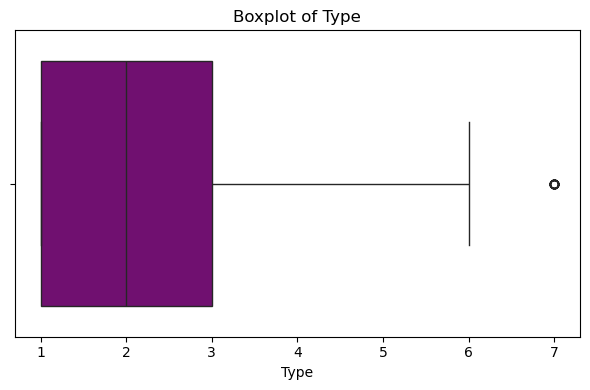

In [104]:
for col in df:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col], color = 'Purple')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [105]:
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR =Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

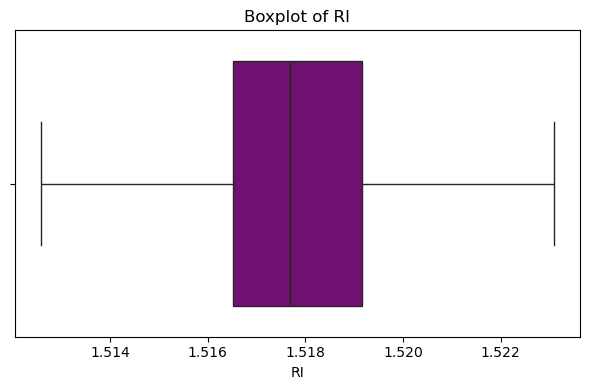

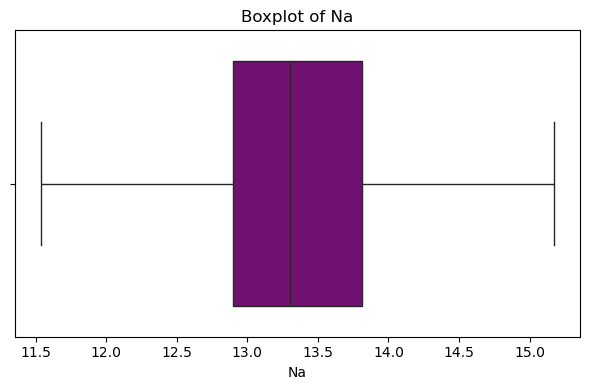

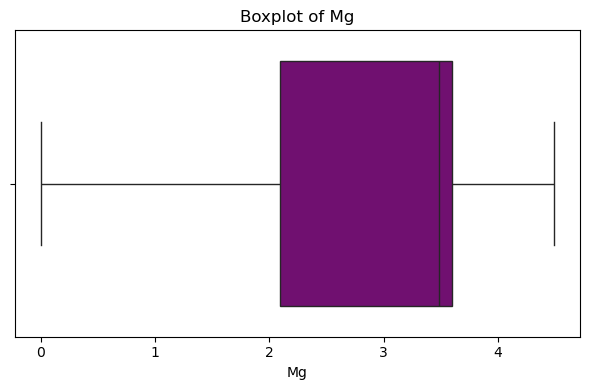

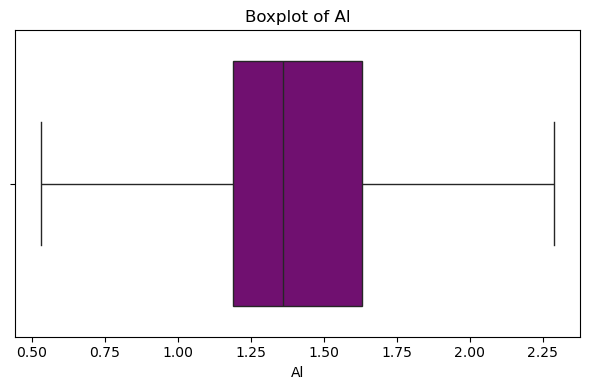

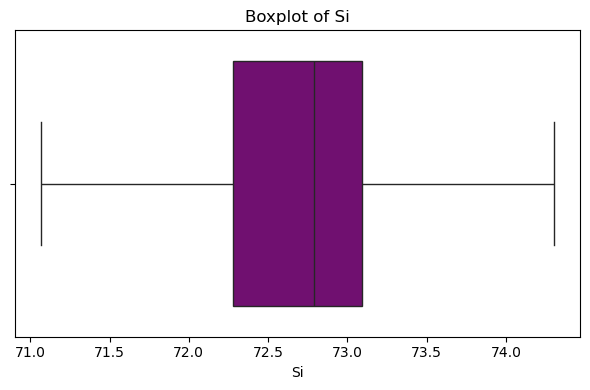

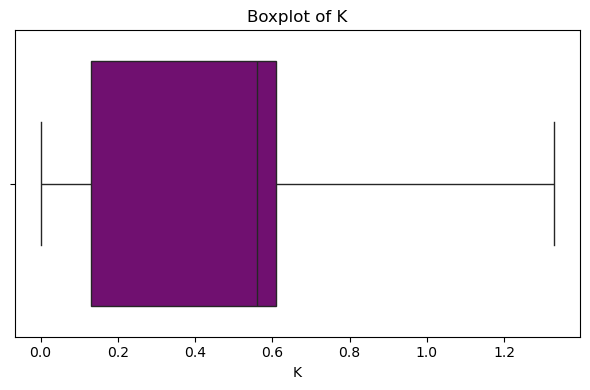

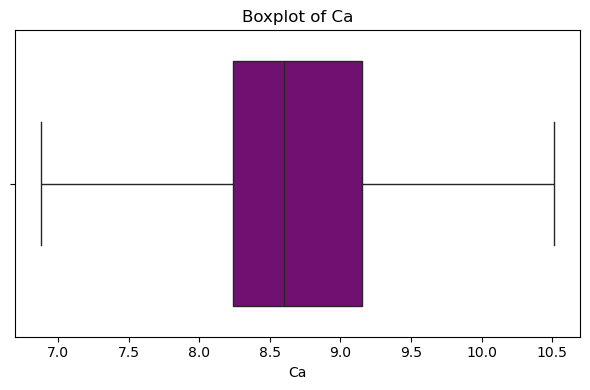

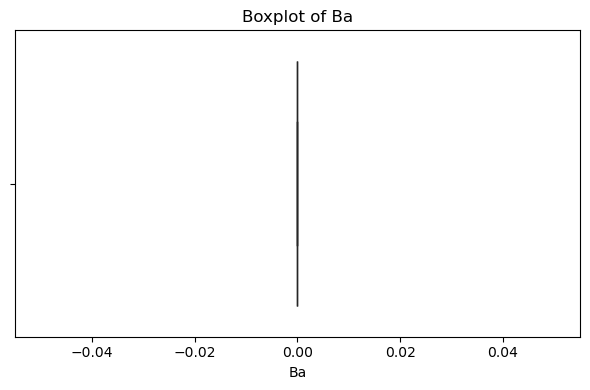

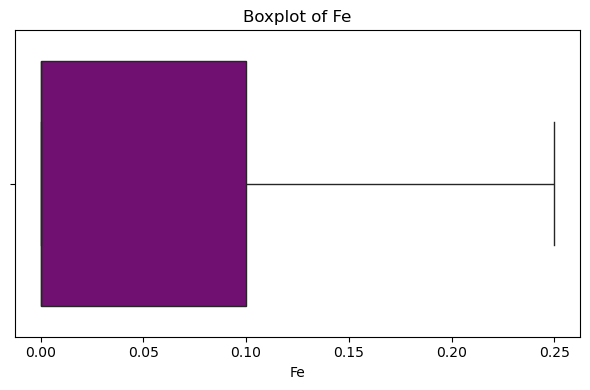

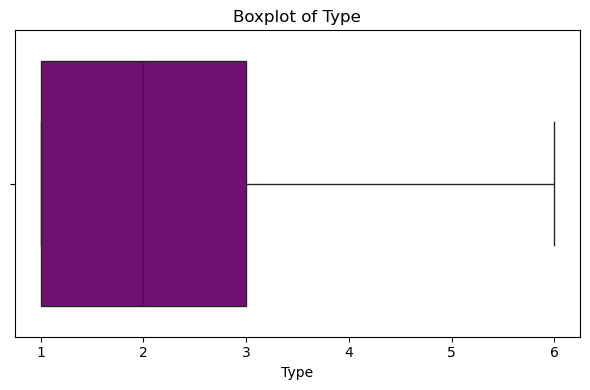

In [106]:
for col in df:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col], color = 'Purple')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

### 2. Data Vizualization 

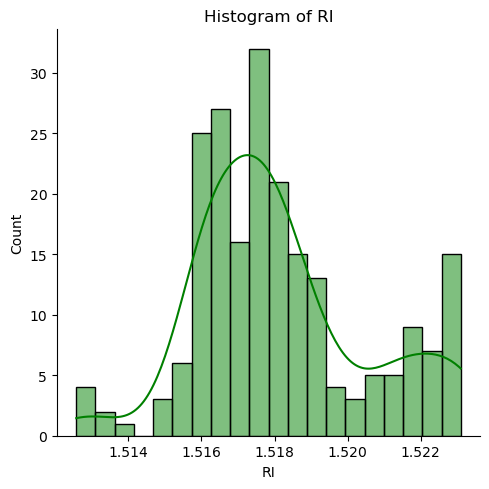

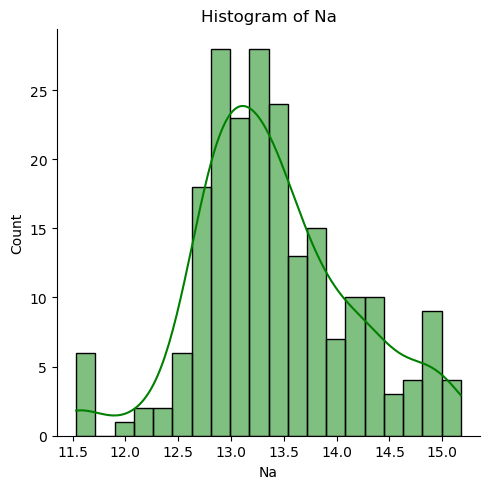

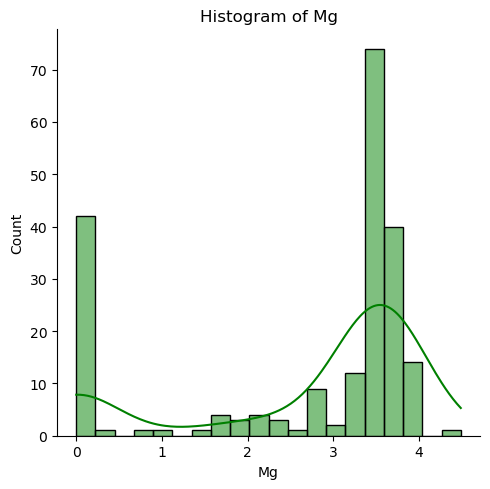

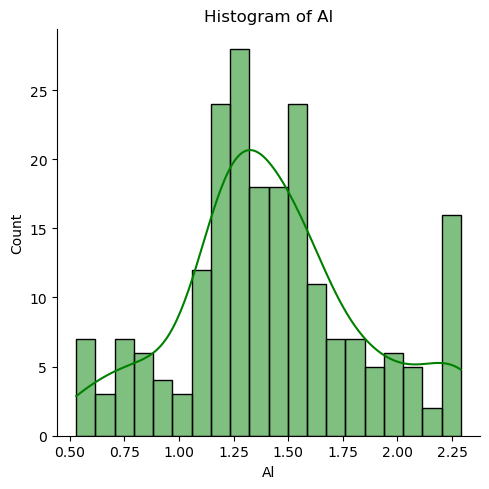

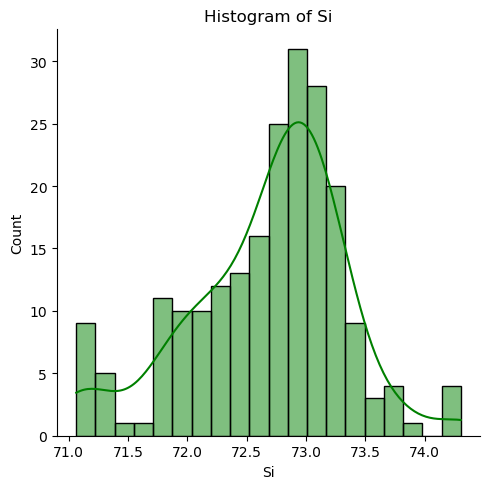

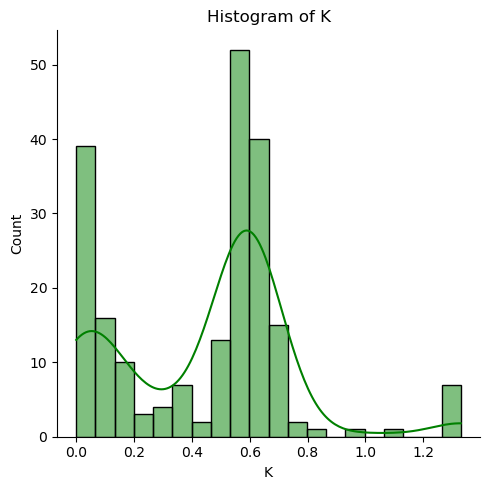

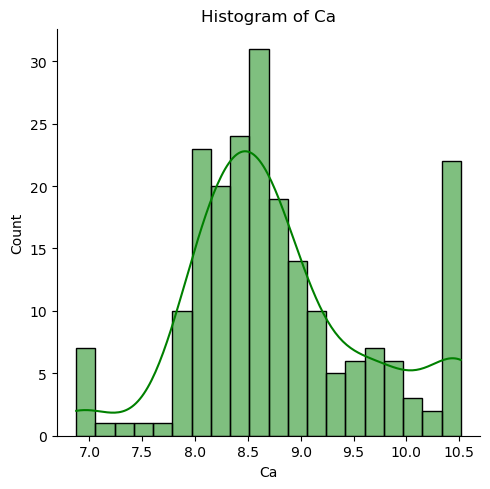

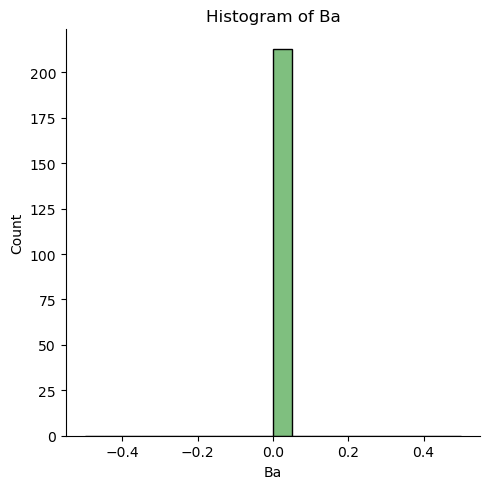

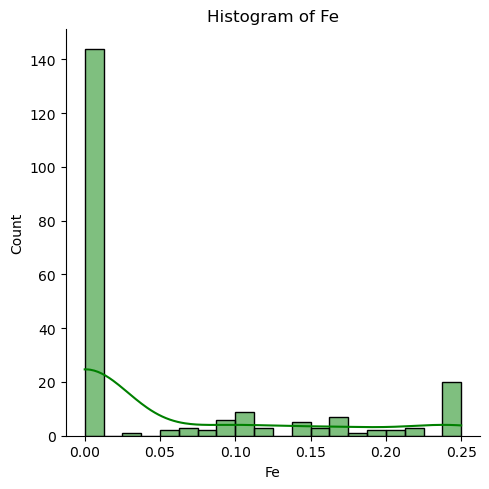

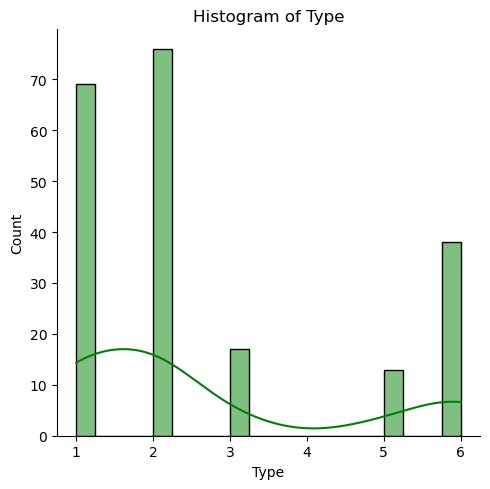

In [107]:
for col in data:
    sns.displot(data=data, x=col, bins=20, kde=True,color='Green')
    plt.title(f"Histogram of {col}")
    plt.tight_layout()
    plt.show()

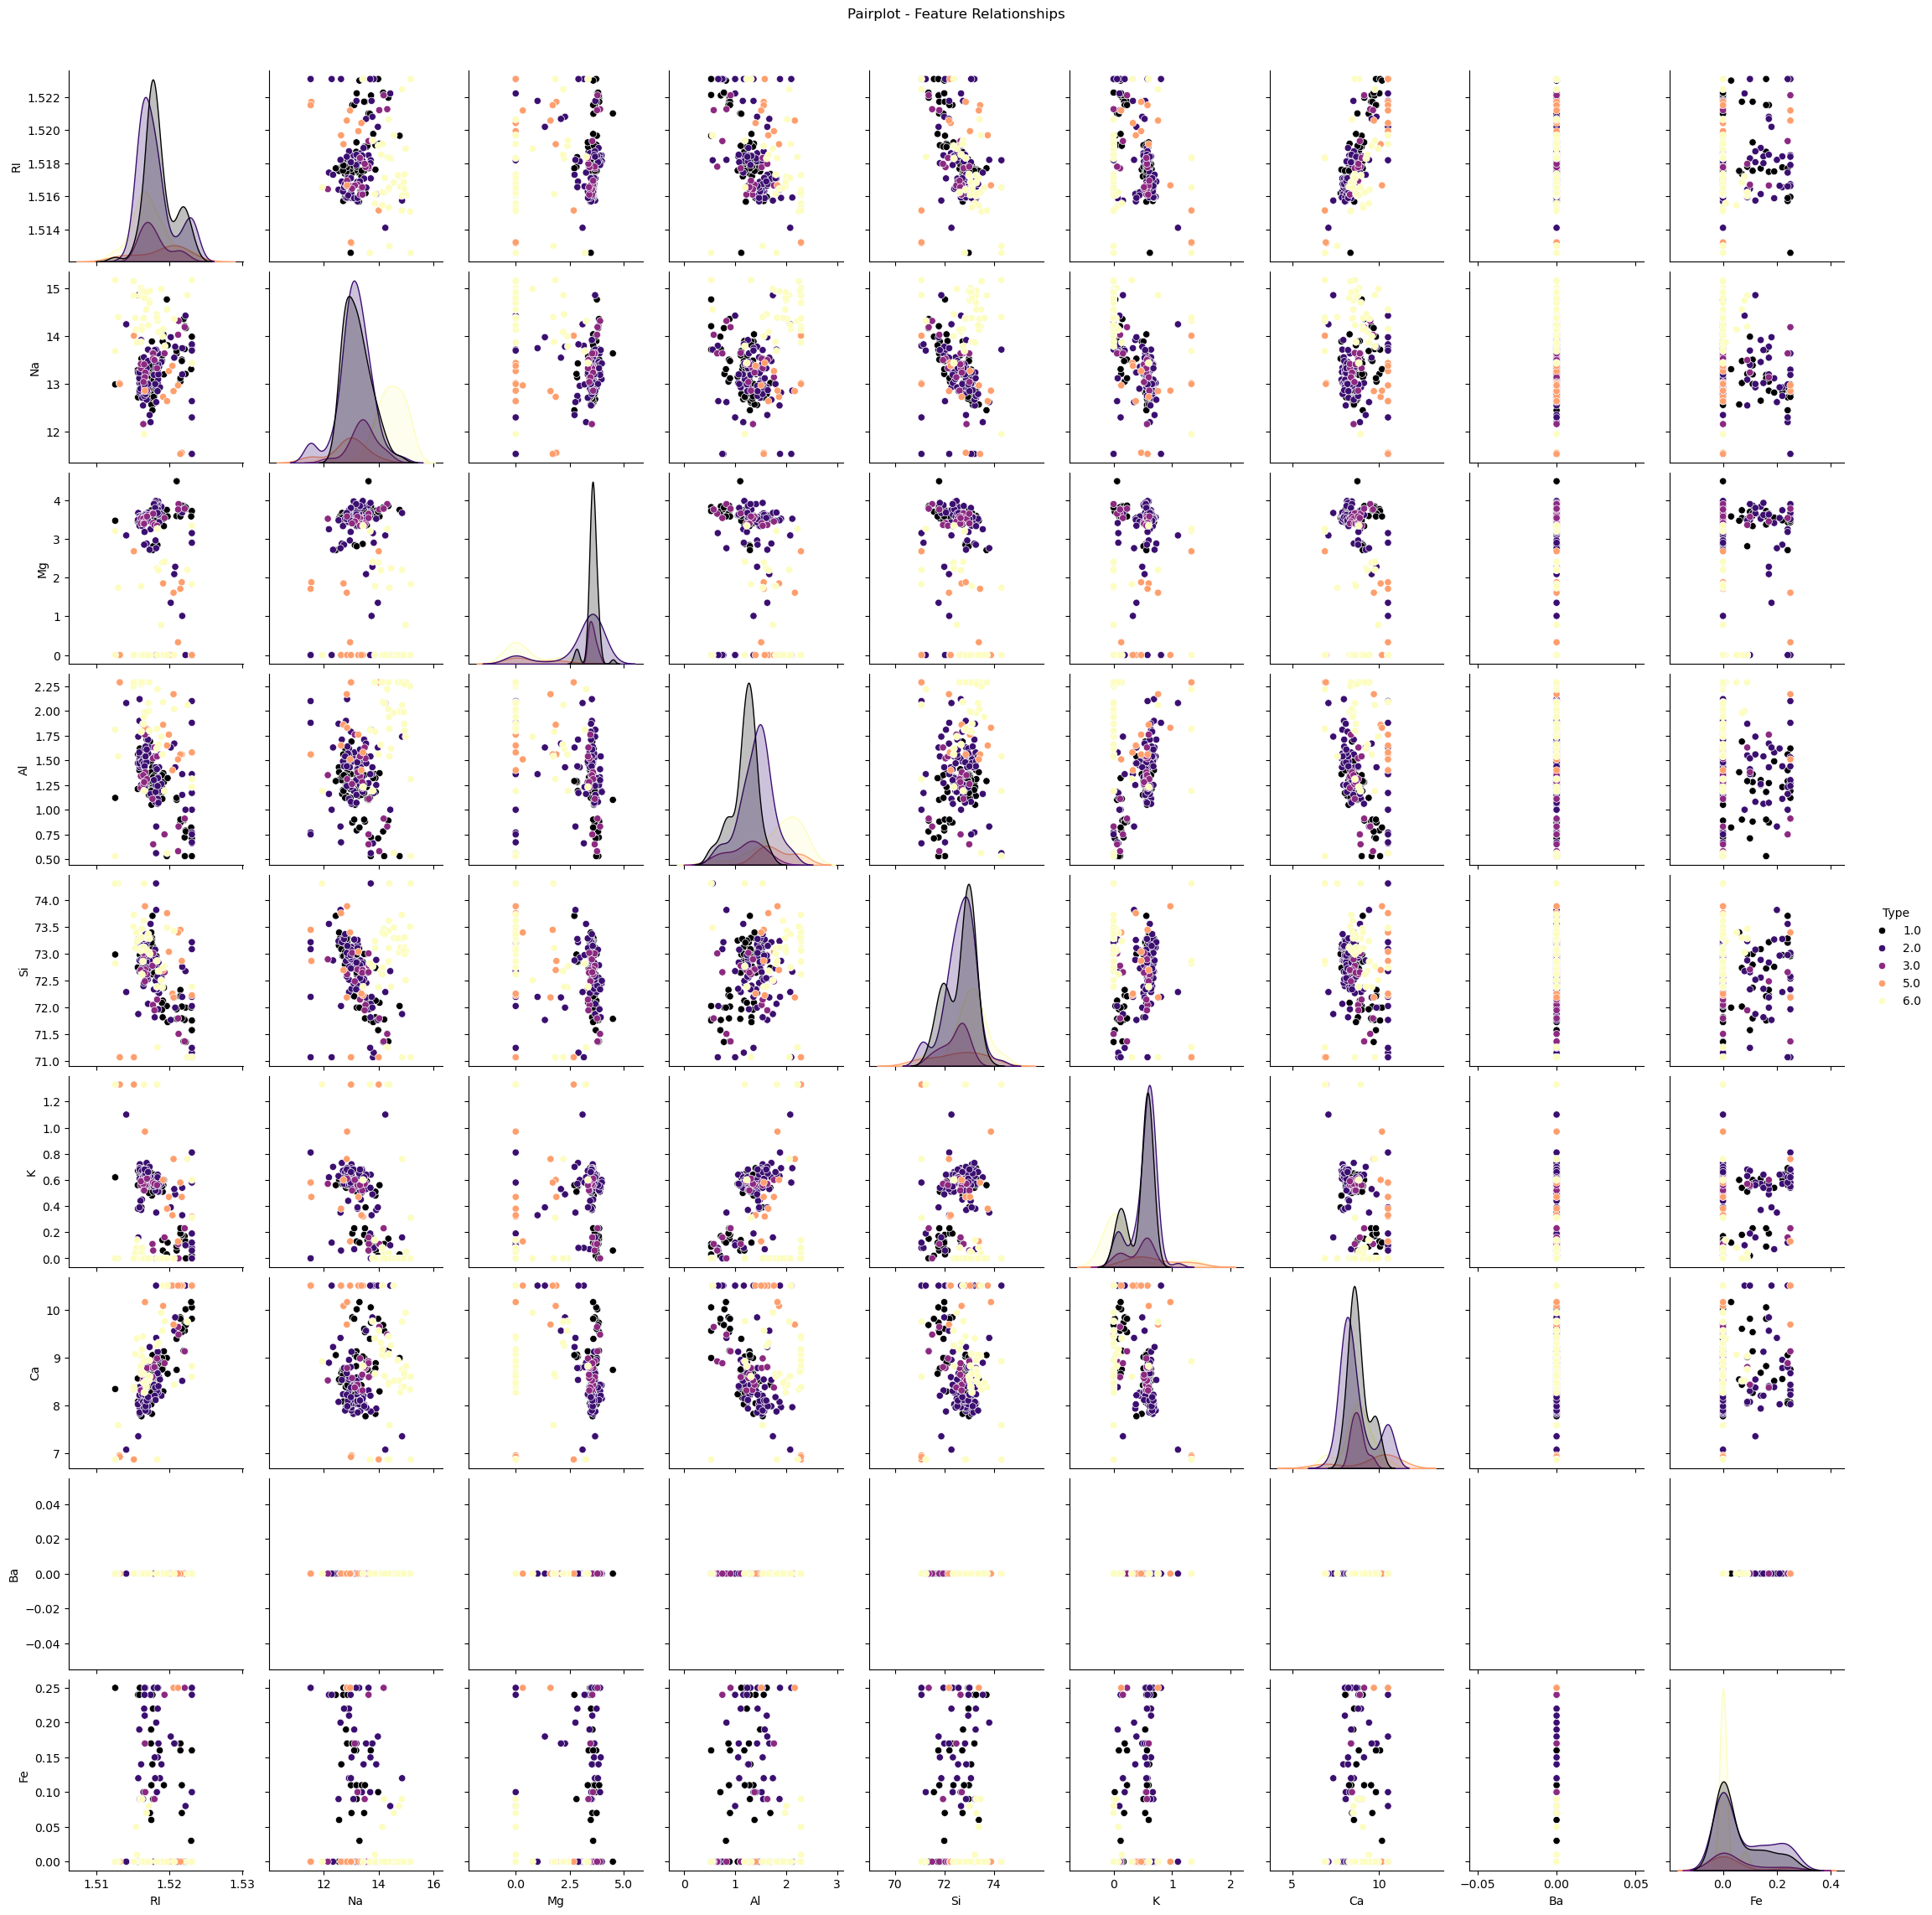

In [108]:
sns.pairplot(df, hue="Type", palette="magma")
plt.suptitle("Pairplot - Feature Relationships", y=1.02)
plt.show()

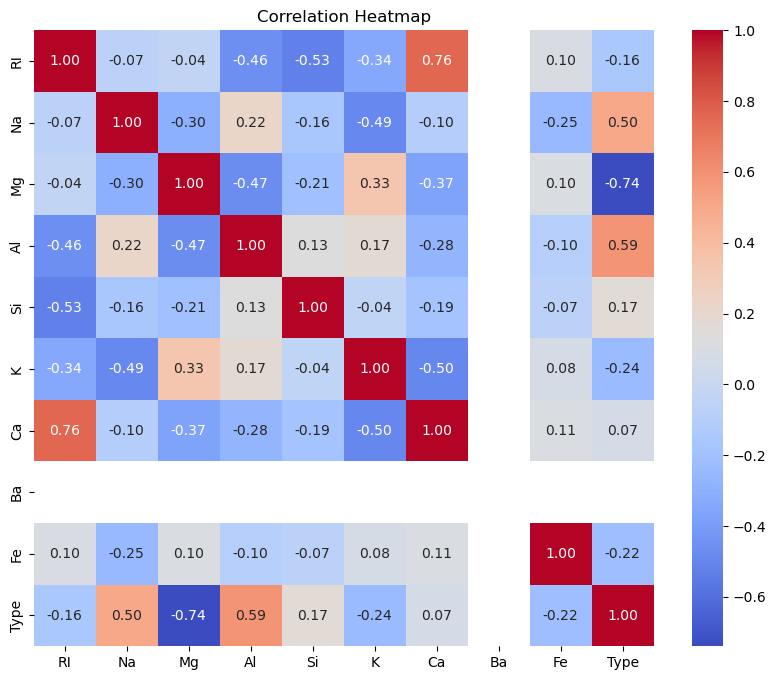

In [109]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 3. Data Preprocessing

In [110]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [111]:
features = df.drop("Type", axis=1)
target = df["Type"]
features
target

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
208    6.0
209    6.0
210    6.0
211    6.0
212    6.0
Name: Type, Length: 213, dtype: float64

In [112]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [113]:
features = pd.DataFrame(X_scaled, columns=df.columns[:-1])
train = pd.concat([features, target], axis=1)

In [114]:
majority_size = train['Type'].value_counts().max()
resampled_list = []

In [115]:
for cls, group in train.groupby('Type'):
    if len(group) < majority_size:
        upsampled = resample(group, replace=True, n_samples=majority_size, random_state=42)
        resampled_list.append(upsampled)
    else:
        resampled_list.append(group)

In [116]:
train_resampled = pd.concat(resampled_list).sample(frac=1, random_state=42)
X_res = train_resampled.drop('Type', axis=1)
y_res = train_resampled['Type']

In [117]:
print("\nAfter upsampling class distribution:\n", y_res.value_counts())


After upsampling class distribution:
 Type
5.0    76
1.0    76
6.0    76
3.0    76
2.0    76
Name: count, dtype: int64


### 4. Random Forest Model 

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, stratify=y_res, random_state=42)


In [119]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [120]:
y_pred = rf.predict(X_test)

In [121]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.88      0.93      0.90        15
         2.0       0.91      0.67      0.77        15
         3.0       0.93      0.93      0.93        15
         5.0       0.84      1.00      0.91        16
         6.0       1.00      1.00      1.00        15

    accuracy                           0.91        76
   macro avg       0.91      0.91      0.90        76
weighted avg       0.91      0.91      0.90        76



In [122]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9078947368421053


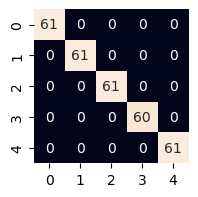

In [123]:
yhat_train = rf.predict(X_train)
cm = confusion_matrix(y_train,yhat_train)
plt.figure(figsize=(2,2))
sns.heatmap(cm,annot=True,fmt='d',cbar=False)
plt.show()

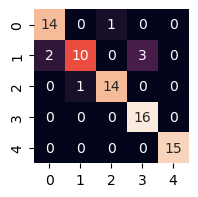

In [124]:
yhat_test = rf.predict(X_test)
cm = confusion_matrix(y_test,yhat_test)
plt.figure(figsize=(2,2))
sns.heatmap(cm, annot=True, cbar=False)
plt.show()

In [125]:
# Feature Importance Plot
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features.columns).sort_values(ascending=False)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8436\2031617444.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette="magma")


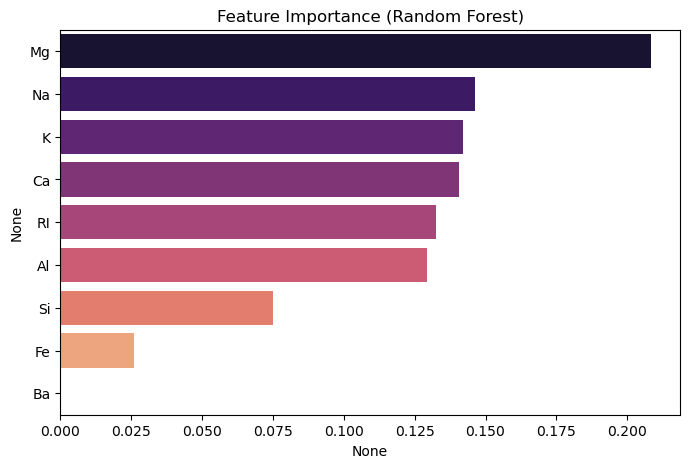

In [126]:
plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="magma")
plt.title("Feature Importance (Random Forest)")
plt.show()

### 5. Bagging and Boosting methods

In [127]:
# Bagging
bag_model = BaggingClassifier(n_estimators=100, random_state=42)
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)


In [128]:
# AdaBoost (Boosting)
boost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
boost_model.fit(X_train, y_train)
y_pred_boost = boost_model.predict(X_test)

In [129]:
# Compare Results
print("\nModel Comparison:\n")

results = pd.DataFrame({
    "Model": ["Random Forest", "Bagging", "AdaBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred_boost)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred_bag, average='macro'),
        f1_score(y_test, y_pred_boost, average='macro')
    ]
})
display(results)


Model Comparison:



,Model,Accuracy,F1 Score
0,Random Forest,0.907895,0.904015
1,Bagging,0.934211,0.930357
2,AdaBoost,0.526316,0.469286


### Additional Notes:
#### 1. Explain Bagging and Boosting methods. How is it different from each other.
#### 2. Explain how to handle imbalance in the data.

### 1. Bagging
#### Trains multiple models on different bootstrap samples of the dataset.
#### Models are trained independently and in parallel.
#### Mainly reduces variance and overfitting.

### Boosting
#### Trains models sequentially, each correcting previous errors.
#### Gives more importance to misclassified data points.
#### Mainly reduces bias and improves accuracy.

### Difference between Bagging and Boosting 
#### Bagging uses parallel training; Boosting uses sequential training.
#### Bagging reduces variance; Boosting reduces bias.
#### Bagging treats all samples equally; Boosting focuses on difficult samples.

### 2  Handling Imbalanced Data
#### Use resampling techniques like oversampling (SMOTE) or undersampling.
#### Apply class weighting or cost-sensitive learning.
#### Evaluate using precision, recall, F1-score instead of accuracy.